In [1]:
import sys
sys.path.append(r"Z:\royj\tools\pipeline")
sys.path.append(r"Z:\royj\tools\pipeline\functions")

# autofluor / sediment RO signal cleaning

In [3]:
import seg_qc_functions as qc 
### load one FOV to get a sense of the distributions 

"""" 
Run without tophat filters to identify problematic regions.
Check different channels
"""

main_dir = r'X:\persky\analysis\zp_ecoli_M902_p2f_020625'
bg_hyb = 23

dilation_db = {
            # '300' : 2, #int : dilation factor
            # '500' : 2,
            # '900' : 3,
            # '1000' : 3,
            # '1400' : 3,
            '3500' : 3,
            '10000' : 15,
            '20000' : 20,
            }

fov_list = [1]#range(40, 45) #[]# [x for x in range(44) if not x in [19,38,39,44]]#[0] #range(28) #range(29, 45)#[0]range(27, 45)
for fov in fov_list:
    print(f'\nfov_{fov}')
    cleaned_mask,results_db = qc.clean_fluor(main_dir,
                                            fov,
                                            bg_hyb,
                                            dilation_db=dilation_db,
                                            channel_list=['A550'], #'A550'
                                            is_unfiltered=False, #what mask to start with? t0? or after props?
                                            is_save = False #can do tests before saving...
                                            )
    # qc.view_fluor_regions(main_dir,fov,cleaned_mask,results_db)


fov_1
removing autofluor cells (make sure you have the image projections...)
 - removing 501 cells


In [24]:
model.save_model(r'Z:\royj\analysis\rbs_auto_211025\segmentation_qc_model.json')

In [4]:
qc.view_fluor_regions(main_dir,fov,cleaned_mask,results_db)

# manually remove cells
 - load images and label bad cells 
 - can load other images to identify fluor artefacts

In [27]:
import seg_qc_functions as qc 

"""" options
    do_fov_manual_qc(main_dir,fov,additional_images=[(1,'A488'),(1,'A647')],brush_size=20)
    qc.show_filtering_results(main_dir,fov)
    qc.reset_segmentations(main_dir,fov_list = [0])
    is_do_again option, allows to peform multiple rounds of correction without having to restart
"""

main_dir = r'Z:\royj\analysis\rbs_auto_211025'
# fov_list = [x for x in range(44) if not x in [19,38,39,44]]
fov_list = range(40)
for fov in fov_list: 
    print(f'fov {fov}')
    qc.do_fov_manual_qc(main_dir,fov,
                        additional_images=[
                            #(10,'A550'),#(8,'A550'),
                            # (5,'A550'),(5,'A647'),(5,'A488'),
                            # (6,'A550'),(6,'A647'),(6,'A488'),
                            # (7,'A550'),(7,'A647'),(7,'A488'),
                        ],
                        brush_size=10,
                        is_relabel = False, 
                        is_overwrite=True,  
                        is_do_again = True #start with the seg.npy rather than the unfiltered
                        ) #(8,'A488'), (8,'A647'), (8, 'A550')
    # qc.reset_segmentations(main_dir,fov_list = fov_list) #do with care

# View the results 
# qc.view_results(main_dir,fov)


fov 0
fov_0_hyb_1
doing qc over previously processed image...
fov 1
fov_1_hyb_1
doing qc over previously processed image...
fov 2
fov_2_hyb_1
doing qc over previously processed image...
fov 3
fov_3_hyb_1
doing qc over previously processed image...
fov 4
fov_4_hyb_1
doing qc over previously processed image...
fov 5
fov_5_hyb_1
doing qc over previously processed image...
fov 6
fov_6_hyb_1
doing qc over previously processed image...
fov 7
fov_7_hyb_1
doing qc over previously processed image...
fov 8
fov_8_hyb_1
doing qc over previously processed image...
fov 9
fov_9_hyb_1
doing qc over previously processed image...
fov 10
fov_10_hyb_1
doing qc over previously processed image...
fov 11
fov_11_hyb_1
doing qc over previously processed image...
fov 12
fov_12_hyb_1
doing qc over previously processed image...
fov 13
fov_13_hyb_1
doing qc over previously processed image...
fov 14
fov_14_hyb_1
doing qc over previously processed image...
fov 15
fov_15_hyb_1
doing qc over previously processed image

In [ ]:
qc.view_results(main_dir,fov)

In [ ]:
import seg_qc_functions as qc 
main_dir = r'V:\danielda\analysis\zp_auto_080524_late_exp_100x'

qc.view_results(main_dir,fov=0)

In [ ]:
import numpy as np

main_dir = r'V:\danielda\analysis\zp_auto_080524_late_exp_100x'
total_cells = 0
for fov in range(40):
    mask = np.load(rf'{main_dir}/segmentation/fov_{fov}_hyb_0/fov_{fov}_hyb_0.seg.npy')
    num_of_cells_in_fov = len(np.unique(mask[mask != 0]))
    print(fov,num_of_cells_in_fov)
    total_cells += num_of_cells_in_fov
total_cells

# filtering by bad demultiplexing 

indicative of tangled cells

In [3]:
from seg_qc_functions import filter_by_demultiplxing_errors   
import napari 

main_dir = r'V:\danielda\analysis\zp_auto_080524_late_exp_100x'
fov_list = range(1)

for fov in fov_list:
    print('fov = ',fov) 
    filter_by_demultiplxing_errors(main_dir,
                                    fov,demult_by = ['genes'], #can also include samples
                                    bad_classes = ['false_positive','too_many_signals'],
                                    strel_size = 6, #how much should we dilate
                                    is_unfiltered=False,
                                    is_save = False
                                    )




fov =  0
filt
false_positive
Series([], Name: cell_id, dtype: int64)
[]
too_many_signals
863      945
886      971
1100    1209
1750    1935
1773    1969
1819    2034
1856    2080
1888    2120
1918    2162
1932    2185
1942    2198
2707    3115
2873    3304
Name: cell_id, dtype: int64
[ 945  945  945 ... 3304 3304 3304]
dropping 13 badly demultiplexed cells together with 39 neighbors


In [8]:
cell_table.valid.value_counts()

valid
True     9149
False     111
Name: count, dtype: int64

In [17]:
import re
def get_fov(name):
    return int(re.match(r'.*fov_(\d+)_.*', name).group(1))

import pandas as pd
import glob
import numpy as np
cell_table = pd.concat([pd.read_csv(file, sep="\t").assign(fov=get_fov(file)) for file in glob.glob(f"{main_dir}/segmentation/*/*.props.txt")])
cell_table = cell_table[cell_table.fov < 7]


valid_cells = set()
for fov in cell_table.fov.unique():
    filtered_masks = np.load(f'{main_dir}/segmentation/fov_{fov}_hyb_1/fov_{fov}_hyb_1.seg.npy')
    for cell_id in np.unique(filtered_masks):
        if cell_id == 0:
            continue
        valid_cells.add((fov, cell_id))

cell_table["valid"] = cell_table.apply(lambda row: (row.fov, row.label) in valid_cells, axis=1)

c:\Users\royj\.conda\envs\pyenv\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:11:07] WARNING: D:\bld\xgboost-split_1757347805659\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


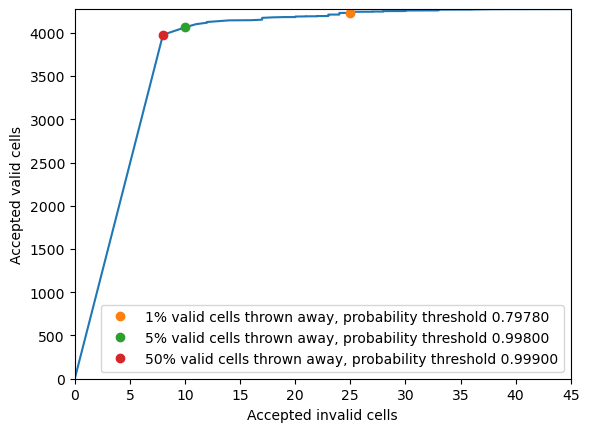

In [19]:
# Use xgboost to learn cell_table.valid and plot ROC curve
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
from xgboost import XGBClassifier
features = ['area', 'perimeter', 'eccentricity', 'major_axis_length',
       'minor_axis_length', 'solidity',
       'convex_area', 'area_ratio', 'perimeter_ratio', 'perim_to_area',
       'axis_ratio', 'circularity']
X = cell_table[features]
y = cell_table['valid'].astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(X_train, y_train)

y_score = model.predict_proba(X_test)[:,  1]

import matplotlib.pyplot as plt
plt.figure()
plt.xlabel("Accepted invalid cells")
plt.ylabel("Accepted valid cells")

thresholds = np.linspace(0, 1, 1000)
def scores(threshold):
    accepted_valid = np.sum((y_score >= threshold) & (y_test == 1))
    accepted_invalid = np.sum((y_score >= threshold) & (y_test == 0))
    return accepted_valid, accepted_invalid

accepted_valid, accepted_invalid = zip(*[scores(t) for t in thresholds])
plt.plot(accepted_invalid, accepted_valid)
plt.xlim(0, max(accepted_invalid))
plt.ylim(0, max(accepted_valid))

# Put the 1%, 5%, 10% of thrown-away valid cells.
for p in [0.01, 0.05, 0.5]:
    idx = np.argmin(np.abs((np.array(accepted_valid) - (1 - p) * np.sum(y_test == 1))))
    plt.plot(accepted_invalid[idx], accepted_valid[idx], 'o', label=f'{p*100:.0f}% valid cells thrown away, probability threshold {thresholds[idx]:.5f}')
plt.legend()

In [25]:
fov_list = range(40)
for fov in fov_list:
    print(f'fov {fov}')
    props = pd.read_csv(f'{main_dir}/segmentation/fov_{fov}_hyb_1/fov_{fov}_hyb_1.props.txt', sep='\t')
    props_for_pred = props[features]
    proba = model.predict_proba(props_for_pred)[:, 1]
    props['valid'] = proba > 0.8
    invalid_cells = list(set(label for label, valid in zip(props['label'], props['valid']) if not valid))
    seg_unfilt = np.load(f'{main_dir}/segmentation/fov_{fov}_hyb_1/fov_{fov}_hyb_1.seg.npy')
    
    manual_mask = seg_unfilt.copy()
    filtered_mask = seg_unfilt.copy()
    filtered_mask[ np.isin(filtered_mask, invalid_cells) ] = 0
    manual_mask[ ~np.isin(manual_mask, invalid_cells) ] = 0

    print("Throwing away {} cells out of {}".format(len(invalid_cells), len(props)))

    np.save(f'{main_dir}/segmentation/fov_{fov}_hyb_1/fov_{fov}_hyb_1.seg.manual_qc.npy', manual_mask)
    np.save(f'{main_dir}/segmentation/fov_{fov}_hyb_1/fov_{fov}_hyb_1.seg.npy', filtered_mask)

fov 0
Throwing away 4 cells out of 1248
fov 1
Throwing away 5 cells out of 1623
fov 2
Throwing away 13 cells out of 2138
fov 3
Throwing away 8 cells out of 1719
fov 4
Throwing away 16 cells out of 2301
fov 5
Throwing away 36 cells out of 2661
fov 6
Throwing away 15 cells out of 2337
fov 7
Throwing away 14 cells out of 1843
fov 8
Throwing away 2 cells out of 1540
fov 9
Throwing away 4 cells out of 1200
fov 10
Throwing away 8 cells out of 1168
fov 11
Throwing away 8 cells out of 1325
fov 12
Throwing away 8 cells out of 1903
fov 13
Throwing away 14 cells out of 1796
fov 14
Throwing away 9 cells out of 1431
fov 15
Throwing away 4 cells out of 1169
fov 16
Throwing away 16 cells out of 1299
fov 17
Throwing away 8 cells out of 1385
fov 18
Throwing away 12 cells out of 1857
fov 19
Throwing away 26 cells out of 2152
fov 20
Throwing away 15 cells out of 1867
fov 21
Throwing away 9 cells out of 1905
fov 22
Throwing away 11 cells out of 1844
fov 23
Throwing away 24 cells out of 2448
fov 24
Throwin

In [26]:
fov_list

range(0, 40)